In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

In [2]:
train_dataset = datasets.MNIST(root = './data', train = True, transform = transform, download = True)
test_dataset = datasets.MNIST(root = './data', train = False, transform = transform, download = True)

In [3]:
train_dataset

Dataset MNIST
    Number of datapoints: 60000
    Root location: ./data
    Split: Train
    StandardTransform
Transform: Compose(
               ToTensor()
               Normalize(mean=(0.1307,), std=(0.3081,))
           )

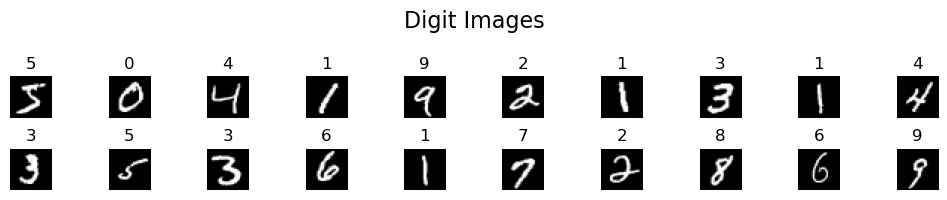

In [4]:
train_loader = DataLoader(train_dataset, batch_size=64, shuffle = True)
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle = False)

def show_samples(dataset, n = 20):
    plt.figure(figsize=(10,2))
    for i in range(n):
        image, label = dataset[i]
        plt.subplot(2, n//2, i+1)
        plt.imshow(image.squeeze(), cmap = 'grey')
        plt.title(label)
        plt.axis('off')
    plt.suptitle("Digit Images", fontsize = 16)
    plt.tight_layout()
    plt.show()

show_samples(train_dataset)
        

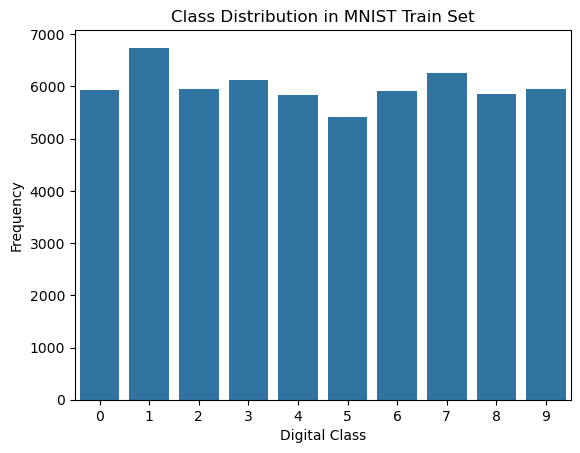

CPU times: total: 12.7 s
Wall time: 12.8 s


In [5]:
%%time
labels = [label for _, label in train_dataset]
sns.countplot(x = labels)
plt.title("Class Distribution in MNIST Train Set")
plt.xlabel("Digital Class")
plt.ylabel("Frequency")
plt.show()

In [6]:
class CNNModel(nn.Module):
    def __init__(self):
        super(CNNModel, self).__init__()
        self.conv1 = nn.Conv2d(1, 16, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.fc1 = nn.Linear(32 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = x.view(-1, 32 * 7 * 7)
        x = torch.relu(self.fc1(x))
        return self.fc2(x)

model = CNNModel()


In [7]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr = 0.001)

In [8]:
%%time
epochs = 5
train_losses = []
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss = running_loss + loss.item()
    avg_loss = running_loss / len(train_loader)
    train_losses.append(avg_loss)
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.5f}")

Epoch [1/5], Loss: 0.15894
Epoch [2/5], Loss: 0.04768
Epoch [3/5], Loss: 0.03238
Epoch [4/5], Loss: 0.02404
Epoch [5/5], Loss: 0.02015
CPU times: total: 18min 29s
Wall time: 4min 53s


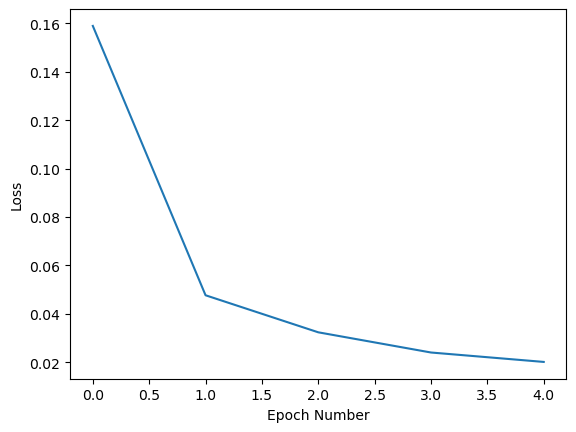

In [11]:
plt.plot(train_losses)
plt.xlabel("Epoch Number")
plt.ylabel("Loss")
plt.show()

In [12]:

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.numpy())
        all_labels.extend(labels.numpy())
print("\nClassification Report:")
print(classification_report(all_labels, all_preds))



Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      1.00      1.00      1135
           2       1.00      0.99      0.99      1032
           3       0.98      1.00      0.99      1010
           4       0.99      1.00      0.99       982
           5       0.99      0.98      0.99       892
           6       0.98      1.00      0.99       958
           7       0.98      0.99      0.99      1028
           8       0.99      0.98      0.99       974
           9       1.00      0.97      0.98      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



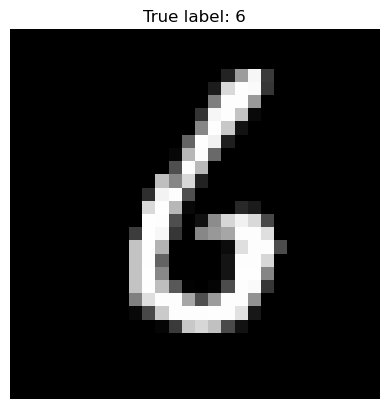

Pridicted class : 6


In [19]:
sample_img, sample_label = test_dataset[50]
plt.imshow(sample_img.squeeze(), cmap = 'grey')
plt.title(f"True label: {sample_label}")
plt.axis('off')
plt.show()

sample_tensor = sample_img.unsqueeze(0)
with torch.no_grad():
    output = model(sample_tensor)
    predicted_class = torch.argmax(output).item()
    print(f"Pridicted class : {predicted_class}")
    